In [2]:
%pip install -q numpy pandas matplotlib scipy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


EXPERIMENT_DIR = Path(
    os.environ.get(
        "EXPERIMENT_DIR",
        "/workspace/suppression-lens/experiment",
    )
)

FIG_DIR = EXPERIMENT_DIR / "figures" / "viz"
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Frozen experiment config
with (EXPERIMENT_DIR / "manifest.json").open() as f:
    manifest = json.load(f)

config = manifest["config"]

EARLY_LAYERS = config["early_layers"]
LAYER_TYPES = config["layer_types"]

FULL_ATTN_LAYERS = [
    i for i, layer_type in enumerate(LAYER_TYPES)
    if layer_type == "full_attention"
]


# Main experiment data
TARGET_SCORES_PATH = (
    EXPERIMENT_DIR / "lens" / "target_scores.csv"
)

BEHAVIORAL_PATH = (
    EXPERIMENT_DIR
    / "behavioral"
    / "behavioral_fact_metrics.csv"
)


# Specificity controls
SPECIFICITY_RESULTS_PATH = (
    EXPERIMENT_DIR
    / "controls"
    / "rlens_random_targets"
    / "control_results.json"
)


# Lexical controls
LEXICAL_RESULTS_PATH = (
    EXPERIMENT_DIR
    / "controls"
    / "rlens_lexical_targets"
    / "control_results.json"
)


for path in [
    TARGET_SCORES_PATH,
    BEHAVIORAL_PATH,
    SPECIFICITY_RESULTS_PATH,
    LEXICAL_RESULTS_PATH,
]:
    assert path.exists(), path


target_scores = pd.read_csv(TARGET_SCORES_PATH)
behavioral = pd.read_csv(BEHAVIORAL_PATH)

with SPECIFICITY_RESULTS_PATH.open() as f:
    specificity_results = json.load(f)

with LEXICAL_RESULTS_PATH.open() as f:
    lexical_results = json.load(f)

In [4]:
# ------------------------------------------------------------
# Visual style — Consensus Knot palette
# ------------------------------------------------------------

TEAL = "#3a9b8f"
COPPER = "#b87333"
OFFWHITE = "#e8e8e6"

BLACK = "#111111"
MIDGRAY = "#777777"
LIGHTGRAY = "#d1d1ce"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "text.color": BLACK,
    "axes.labelcolor": BLACK,
    "axes.edgecolor": BLACK,

    "xtick.color": BLACK,
    "ytick.color": BLACK,

    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.color": LIGHTGRAY,
    "grid.alpha": 0.45,
    "grid.linewidth": 0.7,

    "lines.linewidth": 1.8,
    "lines.markersize": 5,

    "legend.frameon": False,

    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})


METHOD_COLORS = {
    "R": TEAL,
    "J": COPPER,
    "logit": BLACK,
}

In [5]:
# ------------------------------------------------------------
# Fact rank at each method/layer
# ------------------------------------------------------------

fact_layer = (
    target_scores
    .groupby(
        ["question_key", "fact_index", "method", "layer"],
        as_index=False,
    )
    .agg(fact_rank=("target_rank", "min"))
)

assert len(fact_layer) == 368 * 3 * 63
assert fact_layer["fact_rank"].between(1, 248_320).all()

fact_layer["log_rank"] = np.log(fact_layer["fact_rank"])
fact_layer["hit10"] = fact_layer["fact_rank"] <= 10


# ------------------------------------------------------------
# Frozen early-layer metric
# ------------------------------------------------------------

early = fact_layer[
    fact_layer["layer"].isin(EARLY_LAYERS)
].copy()

E = (
    early
    .groupby(
        ["question_key", "fact_index", "method"],
        as_index=False,
    )
    .agg(E=("log_rank", "mean"))
)

E_wide = (
    E.pivot(
        index=["question_key", "fact_index"],
        columns="method",
        values="E",
    )
    .reset_index()
)

E_wide.columns.name = None

assert len(E_wide) == 368
assert E_wide[["J", "R", "logit"]].notna().all().all()

E_wide["D_RJ"] = E_wide["J"] - E_wide["R"]
E_wide["D_Rlogit"] = E_wide["logit"] - E_wide["R"]
E_wide["D_Jlogit"] = E_wide["logit"] - E_wide["J"]


# ------------------------------------------------------------
# Behavioral + lens analysis table
# ------------------------------------------------------------

analysis = behavioral.merge(
    E_wide,
    on=["question_key", "fact_index"],
    how="inner",
    validate="one_to_one",
)

assert len(analysis) == 368


# ------------------------------------------------------------
# Layerwise summaries
# ------------------------------------------------------------

layer_summary = (
    fact_layer
    .groupby(["method", "layer"], as_index=False)
    .agg(
        mean_log_rank=("log_rank", "mean"),
        median_log_rank=("log_rank", "median"),
        recall10=("hit10", "mean"),
    )
)

layer_wide = (
    fact_layer
    .pivot(
        index=["question_key", "fact_index", "layer"],
        columns="method",
        values="log_rank",
    )
    .reset_index()
)

layer_wide.columns.name = None

layer_wide["R_vs_J"] = layer_wide["J"] - layer_wide["R"]
layer_wide["R_vs_logit"] = layer_wide["logit"] - layer_wide["R"]
layer_wide["J_vs_logit"] = layer_wide["logit"] - layer_wide["J"]

advantage_by_layer = (
    layer_wide
    .groupby("layer", as_index=False)
    .agg(
        R_vs_J=("R_vs_J", "mean"),
        R_vs_logit=("R_vs_logit", "mean"),
        J_vs_logit=("J_vs_logit", "mean"),
    )
)

In [8]:
SEED = 111

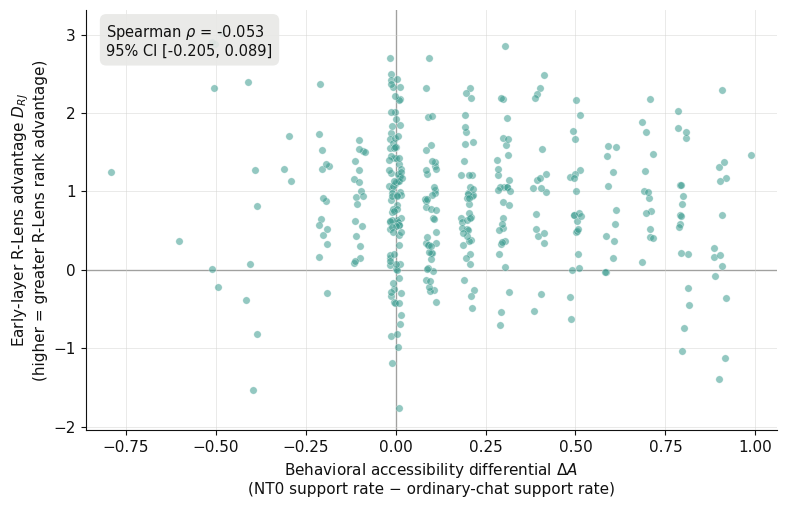

In [11]:
# ------------------------------------------------------------
# Figure 1 — Behavioral accessibility vs R-Lens advantage
# ------------------------------------------------------------

plot_df = analysis.copy()

# ΔA is discrete because behavioral accessibility is estimated
# from a finite number of samples. Small horizontal jitter makes
# overlapping observations visible without changing interpretation.
rng = np.random.default_rng(SEED)

plot_df["DeltaA_jitter"] = (
    plot_df["DeltaA"]
    + rng.uniform(
        -0.018,
        0.018,
        size=len(plot_df),
    )
)


fig, ax = plt.subplots(figsize=(8.0, 5.2))

ax.scatter(
    plot_df["DeltaA_jitter"],
    plot_df["D_RJ"],
    s=28,
    color=TEAL,
    alpha=0.55,
    edgecolors="white",
    linewidths=0.35,
    zorder=3,
)

# Reference axes: no behavioral change, no R-vs-J advantage
ax.axhline(
    0,
    color=BLACK,
    linewidth=0.9,
    alpha=0.55,
    zorder=1,
)

ax.axvline(
    0,
    color=BLACK,
    linewidth=0.9,
    alpha=0.55,
    zorder=1,
)


ax.set_xlabel(
    r"Behavioral accessibility differential $\Delta A$"
    "\n"
    "(NT0 support rate − ordinary-chat support rate)"
)

ax.set_ylabel(
    r"Early-layer R-Lens advantage $D_{RJ}$"
    "\n"
    "(higher = greater R-Lens rank advantage)"
)
# Figure-specific statistics
observed_rho = spearmanr(
    analysis["DeltaA"],
    analysis["D_RJ"],
).statistic


# Pre-extract question groups as NumPy arrays so the bootstrap
# doesn't repeatedly filter/concatenate Pandas DataFrames.
groups = [
    (
        g["DeltaA"].to_numpy(),
        g["D_RJ"].to_numpy(),
    )
    for _, g in analysis.groupby("question_key", sort=False)
]

rng_boot = np.random.default_rng(SEED)

boot_rhos = np.empty(10_000)

for b in range(10_000):
    # Hierarchical level 1: resample questions
    sampled_questions = rng_boot.integers(
        0,
        len(groups),
        size=len(groups),
    )

    xs = []
    ys = []

    # Hierarchical level 2: resample facts within each question
    for qi in sampled_questions:
        x, y = groups[qi]

        sampled_facts = rng_boot.integers(
            0,
            len(x),
            size=len(x),
        )

        xs.append(x[sampled_facts])
        ys.append(y[sampled_facts])

    boot_rhos[b] = spearmanr(
        np.concatenate(xs),
        np.concatenate(ys),
    ).statistic


boot_rhos = boot_rhos[np.isfinite(boot_rhos)]

ci_low, ci_high = np.quantile(
    boot_rhos,
    [0.025, 0.975],
)

# Result annotation
stats_text = (
    rf"Spearman $\rho$ = {observed_rho:.3f}"
    "\n"
    rf"95% CI [{ci_low:.3f}, {ci_high:.3f}]"
)

ax.text(
    0.03,
    0.97,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": OFFWHITE,
        "edgecolor": "none",
        "alpha": 0.9,
    },
)


ax.grid(True, zorder=0)

# A little breathing room around the data
ax.margins(x=0.04, y=0.06)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig1_accessibility_vs_rj.svg",
)

fig.savefig(
    FIG_DIR / "fig1_accessibility_vs_rj.png",
    dpi=300,
)

plt.show()

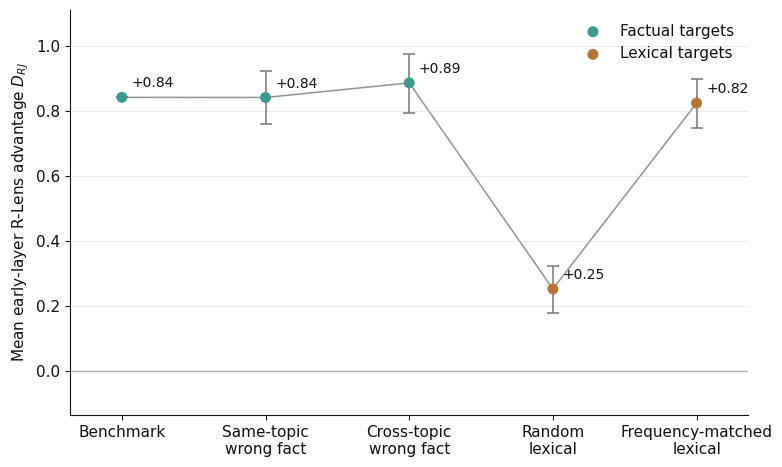

In [14]:
# ------------------------------------------------------------
# Figure 2 — Control ladder
# ------------------------------------------------------------

def randomized_row(label, result):
    lo, hi = result["randomized_95pct"]

    return {
        "condition": label,
        "mean": result["randomized_mean"],
        "lo": lo,
        "hi": hi,
    }


benchmark = (
    specificity_results["same_topic"]["D_RJ"]["true_mean"]
)

ladder = pd.DataFrame([
    {
        "condition": "Benchmark",
        "mean": benchmark,
        "lo": benchmark,
        "hi": benchmark,
    },
    randomized_row(
        "Same-topic\nwrong fact",
        specificity_results["same_topic"]["D_RJ"],
    ),
    randomized_row(
        "Cross-topic\nwrong fact",
        specificity_results["cross_topic"]["D_RJ"],
    ),
    randomized_row(
        "Random\nlexical",
        lexical_results["lexical_random"]["D_RJ"],
    ),
    randomized_row(
        "Frequency-matched\nlexical",
        lexical_results["frequency_matched"]["D_RJ"],
    ),
])


x = np.arange(len(ladder))

means = ladder["mean"].to_numpy()
lower = ladder["lo"].to_numpy()
upper = ladder["hi"].to_numpy()

yerr = np.vstack([
    means - lower,
    upper - means,
])


fig, ax = plt.subplots(figsize=(8.0, 4.8))


# Structural connector
ax.plot(
    x,
    means,
    color=BLACK,
    linewidth=1.1,
    alpha=0.45,
    zorder=1,
)


# Randomized-control ranges
ax.errorbar(
    x,
    means,
    yerr=yerr,
    fmt="none",
    ecolor=MIDGRAY,
    elinewidth=1.1,
    capsize=4,
    capthick=1.1,
    zorder=2,
)


# Factual-target controls
ax.scatter(
    x[:3],
    means[:3],
    s=62,
    color=TEAL,
    edgecolors="none",
    zorder=3,
    label="Factual targets",
)


# Lexical controls
ax.scatter(
    x[3:],
    means[3:],
    s=62,
    color=COPPER,
    edgecolors="none",
    zorder=3,
    label="Lexical targets",
)


ax.axhline(
    0,
    color=BLACK,
    linewidth=0.9,
    alpha=0.45,
    zorder=0,
)


ax.set_xticks(x)
ax.set_xticklabels(ladder["condition"])

ax.set_ylabel(
    r"Mean early-layer R-Lens advantage $D_{RJ}$"
)


# Direct value labels
for xi, value in zip(x, means):
    ax.annotate(
        f"{value:+.2f}",
        (xi, value),
        xytext=(7, 5),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=10,
    )


ax.grid(True, axis="y", zorder=0)
ax.legend()

ax.margins(x=0.09, y=0.14)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig2_control_ladder.svg",
)

fig.savefig(
    FIG_DIR / "fig2_control_ladder.png",
    dpi=300,
)

plt.show()

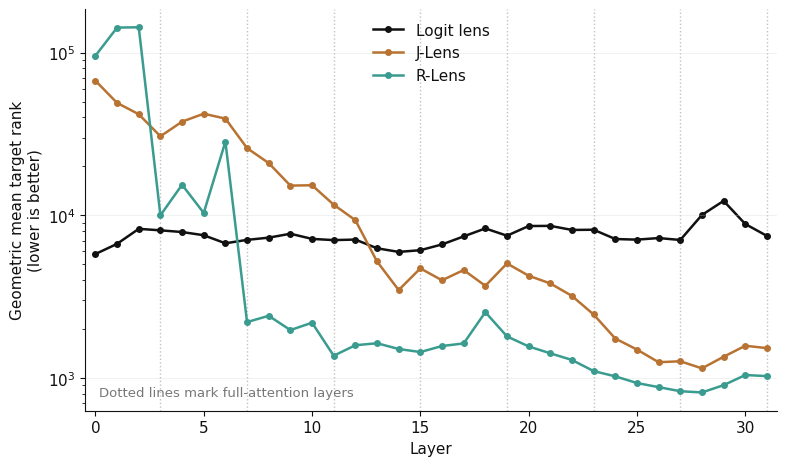

In [18]:
# ------------------------------------------------------------
# Figure 3 — Layerwise target rank
# ------------------------------------------------------------

early_summary = (
    layer_summary[
        layer_summary["layer"].isin(EARLY_LAYERS)
    ]
    .copy()
)

# mean(log(rank)) -> geometric mean rank
early_summary["geomean_rank"] = np.exp(
    early_summary["mean_log_rank"]
)


fig, ax = plt.subplots(figsize=(8.0, 4.8))


method_style = {
    "R": {
        "label": "R-Lens",
        "color": TEAL,
        "zorder": 3,
    },
    "J": {
        "label": "J-Lens",
        "color": COPPER,
        "zorder": 2,
    },
    "logit": {
        "label": "Logit lens",
        "color": BLACK,
        "zorder": 1,
    },
}


for method in ["logit", "J", "R"]:
    d = early_summary[
        early_summary["method"] == method
    ]

    style = method_style[method]

    ax.plot(
        d["layer"],
        d["geomean_rank"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        color=style["color"],
        label=style["label"],
        zorder=style["zorder"],
    )

# Full-attention layers
for layer in FULL_ATTN_LAYERS:
    if layer in EARLY_LAYERS:
        ax.axvline(
            layer,
            color=MIDGRAY,
            linestyle=":",
            linewidth=1.0,
            alpha=0.45,
            zorder=0,
        )


# Rank is multiplicative, so log scale is the natural display.
ax.set_yscale("log")

ax.set_xlabel("Layer")
ax.set_ylabel(
    "Geometric mean target rank\n"
    "(lower is better)"
)

ax.grid(
    True,
    axis="y",
    which="major",
    alpha=0.30,
    zorder=0,
)

ax.text(
    0.02,
    0.03,
    "Dotted lines mark full-attention layers",
    transform=ax.transAxes,
    fontsize=9.5,
    color=MIDGRAY,
    ha="left",
    va="bottom",
)

ax.legend(
    loc="best",
)

ax.margins(x=0.015)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig3_layerwise_rank.svg",
)

fig.savefig(
    FIG_DIR / "fig3_layerwise_rank.png",
    dpi=300,
)

plt.show()